## 0. Install Dependencies

Run this cell first if packages are not installed:

In [3]:
!pip3 install torch --index-url https://download.pytorch.org/whl/cpu transformers xgboost matplotlib seaborn keras --no-cache-dir

Looking in indexes: https://download.pytorch.org/whl/cpu


# AI vs Human Text Classifier - Model Performance Evaluation

This notebook evaluates three trained models:
1. **DistilBERT** - Transformer-based model
2. **Semantic NN** - Neural network with semantic features
3. **XGBoost** - Gradient boosting model

The evaluation includes:
- Detailed performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
- Confusion matrices
- Comparative visualizations

## 1. Import Required Libraries

In [4]:
import os
os.environ['KERAS_BACKEND'] = 'torch'  # Use PyTorch as backend

import keras
import torch
import numpy as np
import pandas as pd
import json
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, classification_report
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import for XGBoost feature extraction
try:
    import spacy
    import textstat
    nlp = spacy.load("en_core_web_md")
    print("✓ Loaded spaCy model for feature extraction")
except Exception as e:
    print(f"⚠ Warning: Could not load spaCy. XGBoost evaluation may fail. Error: {e}")
    nlp = None

print("✓ All libraries imported successfully")

✓ Loaded spaCy model for feature extraction
✓ All libraries imported successfully


## 2. Load Test Dataset

In [5]:
print("Loading test dataset...")
df = pd.read_csv('/home/SexyLadGD/Downloads/NLP models/test_set1.csv')

# Use the test set for evaluation
test_texts = df['text'].tolist()
test_labels = df['is_ai'].tolist()

print(f"✓ Loaded {len(test_texts)} test samples")
print(f"  - AI-written: {sum(test_labels)} ({sum(test_labels)/len(test_labels)*100:.1f}%)")
print(f"  - Human-written: {len(test_labels)-sum(test_labels)} ({(len(test_labels)-sum(test_labels))/len(test_labels)*100:.1f}%)")

# Display sample data
df.head()

Loading test dataset...
✓ Loaded 208 test samples
  - AI-written: 104 (50.0%)
  - Human-written: 104 (50.0%)


,text,author,is_ai
0,Hercules. His dress was rich with a richness w...,Arthur Conan Doyle,0
1,"The chill November air clung to Baker Street, ...",Arthur Conan Doyle,1
2,"but, in his indecision, met her glance. The yo...",Charles Dickens,0
3,"pauses of his quick and laboured breathing, he...",Charles Dickens,0
4,"from Defarge. And so, under a short grove of f...",Charles Dickens,0


## 3. Define Evaluation Functions

In [6]:
def evaluate_model_performance(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """Calculate comprehensive performance metrics"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average='binary')
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    roc_auc = roc_auc_score(y_true, y_pred_proba) if y_pred_proba is not None else None
    
    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'sensitivity': sensitivity,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'true_positives': int(tp),
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn)
    }
    
    return results

def print_performance_report(results):
    """Print detailed performance report"""
    print(f"\n{'='*70}")
    print(f"Performance Report: {results['model_name']}")
    print(f"{'='*70}")
    print(f"Accuracy:      {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
    print(f"Precision:     {results['precision']:.4f}")
    print(f"Recall:        {results['recall']:.4f}")
    print(f"F1-Score:      {results['f1_score']:.4f}")
    print(f"Specificity:   {results['specificity']:.4f}")
    print(f"Sensitivity:   {results['sensitivity']:.4f}")
    
    if results['roc_auc'] is not None:
        print(f"ROC-AUC:       {results['roc_auc']:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"                    Predicted")
    print(f"                Human      AI")
    print(f"Actual Human    {results['true_negatives']:>6}  {results['false_positives']:>6}")
    print(f"       AI       {results['false_negatives']:>6}  {results['true_positives']:>6}")
    print(f"{'='*70}\n")

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## 4. Evaluate DistilBERT Model

In [17]:
print("Evaluating DistilBERT model...")
try:
    distilbert_model = AutoModelForSequenceClassification.from_pretrained(
        '/home/SexyLadGD/Downloads/NLP models/Distilbert model'
    )
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    
    # Predict in batches to avoid memory issues
    batch_size = 16
    all_predictions = []
    all_probabilities = []
    
    print(f"Processing {len(test_texts)} samples in batches of {batch_size}...")
    for i in range(0, len(test_texts), batch_size):
        batch_texts = test_texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
        
        with torch.no_grad():
            outputs = distilbert_model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            probabilities = torch.softmax(outputs.logits, dim=-1)[:, 1]
            
            all_predictions.extend(predictions.numpy())
            all_probabilities.extend(probabilities.numpy())
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i + len(batch_texts)}/{len(test_texts)} samples...")
    
    distilbert_results = evaluate_model_performance(
        test_labels, 
        all_predictions, 
        all_probabilities,
        "DistilBERT"
    )
    print_performance_report(distilbert_results)
    print("✓ DistilBERT evaluation complete")
    
except Exception as e:
    print(f"✗ Error evaluating DistilBERT: {e}")
    distilbert_results = None

Evaluating DistilBERT model...


Loading weights:   1%|          | 1/104 [00:00<00:00, 54471.48it/s, Materializing param=classifier.bias]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1116.23it/s, Materializing param=pre_classifier.weight]                                  


Processing 208 samples in batches of 16...
  Processed 160/208 samples...

Performance Report: DistilBERT
Accuracy:      0.9904 (99.04%)
Precision:     0.9811
Recall:        1.0000
F1-Score:      0.9905
Specificity:   0.9808
Sensitivity:   1.0000
ROC-AUC:       1.0000

Confusion Matrix:
                    Predicted
                Human      AI
Actual Human       102       2
       AI            0     104

✓ DistilBERT evaluation complete


## 5. Evaluate Semantic NN Model

In [18]:
print("Evaluating Semantic NN model...")
try:
    semantic_model = keras.models.load_model(
        '/home/SexyLadGD/Downloads/NLP models/semantic_nnmodel',
        compile=False
    )
    
    # Get expected input dimension from model
    expected_input_dim = semantic_model.input_shape[1]
    print(f"Model expects input dimension: {expected_input_dim}")
    
    # Load GloVe embeddings
    print("Loading GloVe embeddings from glove.6B.100d.txt...")
    glove_path = '/home/SexyLadGD/Downloads/NLP models/glove.6B.100d.txt'
    glove_embeddings = {}
    
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_embeddings[word] = vector
    
    print(f"✓ Loaded {len(glove_embeddings)} word vectors")
    
    # Convert texts to GloVe document vectors
    def text_to_glove_vector(text):
        """Convert text to averaged GloVe embedding"""
        words = text.lower().split()
        word_vectors = []
        
        for word in words:
            if word in glove_embeddings:
                word_vectors.append(glove_embeddings[word])
        
        if len(word_vectors) > 0:
            return np.mean(word_vectors, axis=0)
        else:
            # Return zero vector if no words found in GloVe
            return np.zeros(expected_input_dim)
    
    print("Converting test texts to GloVe vectors...")
    X_test = np.array([text_to_glove_vector(text) for text in test_texts])
    print(f"✓ Created feature matrix with shape: {X_test.shape}")
    
    # Predict
    print("Making predictions...")
    predictions_proba = semantic_model.predict(X_test, batch_size=32, verbose=0)
    predictions = (predictions_proba > 0.5).astype(int).flatten()
    
    semantic_results = evaluate_model_performance(
        test_labels,
        predictions,
        predictions_proba.flatten(),
        "Semantic NN"
    )
    print_performance_report(semantic_results)
    print("✓ Semantic NN evaluation complete")
    
except Exception as e:
    print(f"✗ Error evaluating Semantic NN: {e}")
    import traceback
    traceback.print_exc()
    semantic_results = None

Evaluating Semantic NN model...
Model expects input dimension: 100
Loading GloVe embeddings from glove.6B.100d.txt...
✓ Loaded 400000 word vectors
Converting test texts to GloVe vectors...
✓ Created feature matrix with shape: (208, 100)
Making predictions...

Performance Report: Semantic NN
Accuracy:      0.9567 (95.67%)
Precision:     0.9204
Recall:        1.0000
F1-Score:      0.9585
Specificity:   0.9135
Sensitivity:   1.0000
ROC-AUC:       0.9985

Confusion Matrix:
                    Predicted
                Human      AI
Actual Human        95       9
       AI            0     104

✓ Semantic NN evaluation complete


## 6. Evaluate XGBoost Model

In [19]:
print("Evaluating XGBoost model...")
try:
    if nlp is None:
        raise Exception("spaCy model not loaded. Install with: pip install spacy textstat && python -m spacy download en_core_web_md")
    
    # Define feature extraction function (same as training)
    def extract_features(text):
        doc = nlp(text)
        tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]
        
        # TTR
        ttr = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0
        
        # POS Ratios
        common_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'SCONJ', 'CCONJ', 'PART', 'INTJ']
        pos_counts = {tag: 0 for tag in common_pos}
        total_pos_tokens = 0
        
        for token in doc:
            if not token.is_punct and not token.is_space:
                total_pos_tokens += 1
                if token.pos_ in pos_counts:
                    pos_counts[token.pos_] += 1
        
        pos_ratios = {f"{tag.lower()}_ratio": count / total_pos_tokens if total_pos_tokens > 0 else 0
                      for tag, count in pos_counts.items()}
        
        # Readability
        readability = textstat.flesch_kincaid_grade(text)
        
        features = {"ttr": ttr, "readability": readability}
        features.update(pos_ratios)
        return features
    
    # Extract features from test texts
    print("Extracting linguistic features from test texts...")
    test_features = pd.DataFrame([extract_features(text) for text in test_texts])
    
    # Ensure feature order matches training
    feature_columns = ['ttr', 'readability', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 
                      'pron_ratio', 'det_ratio', 'adp_ratio', 'aux_ratio', 'sconj_ratio', 
                      'cconj_ratio', 'part_ratio', 'intj_ratio']
    X_test_xgb = test_features[feature_columns].fillna(0).values
    
    print(f"✓ Extracted {X_test_xgb.shape[1]} features from {X_test_xgb.shape[0]} samples")
    
    # Load model
    xgb_model = xgb.Booster()
    xgb_model.load_model('/home/SexyLadGD/Downloads/NLP models/Xgboost model/xgboost_ai_detector.json')
    
    # Predict
    dtest = xgb.DMatrix(X_test_xgb, feature_names=feature_columns)
    print("Making predictions...")
    xgb_proba = xgb_model.predict(dtest)
    xgb_predictions = (xgb_proba > 0.5).astype(int)
    
    xgb_results = evaluate_model_performance(
        test_labels,
        xgb_predictions,
        xgb_proba,
        "XGBoost"
    )
    print_performance_report(xgb_results)
    print("✓ XGBoost evaluation complete")
    
except Exception as e:
    print(f"✗ Error evaluating XGBoost: {e}")
    import traceback
    traceback.print_exc()
    xgb_results = None

Evaluating XGBoost model...
Extracting linguistic features from test texts...
✓ Extracted 14 features from 208 samples
Making predictions...

Performance Report: XGBoost
Accuracy:      0.9327 (93.27%)
Precision:     0.8879
Recall:        0.9904
F1-Score:      0.9364
Specificity:   0.8750
Sensitivity:   0.9904
ROC-AUC:       0.9925

Confusion Matrix:
                    Predicted
                Human      AI
Actual Human        91      13
       AI            1     103

✓ XGBoost evaluation complete


## 7. Combined Performance Comparison

In [20]:
print("Generating comparison analysis...")
all_results = [r for r in [distilbert_results, semantic_results, xgb_results] if r is not None]

if len(all_results) > 0:
    print(f"\n{'='*90}")
    print(f"{'MODEL PERFORMANCE COMPARISON':^90}")
    print(f"{'='*90}")
    print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>11} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
    print(f"{'-'*90}")
    
    for result in all_results:
        roc_str = f"{result['roc_auc']:.4f}" if result['roc_auc'] is not None else "N/A"
        print(f"{result['model_name']:<20} {result['accuracy']:>10.4f} {result['precision']:>11.4f} "
              f"{result['recall']:>10.4f} {result['f1_score']:>10.4f} {roc_str:>10}")
    
    print(f"{'='*90}\n")
    
    # Display confusion matrix breakdown
    print(f"\n{'='*90}")
    print(f"{'CONFUSION MATRIX BREAKDOWN':^90}")
    print(f"{'='*90}")
    print(f"{'Model':<20} {'True Pos':>10} {'True Neg':>10} {'False Pos':>11} {'False Neg':>11}")
    print(f"{'-'*90}")
    
    for result in all_results:
        print(f"{result['model_name']:<20} {result['true_positives']:>10} {result['true_negatives']:>10} "
              f"{result['false_positives']:>11} {result['false_negatives']:>11}")
    
    print(f"{'='*90}\n")
    
    # Find best model
    best_model = max(all_results, key=lambda x: x['f1_score'])
    print(f"🏆 Best Model: {best_model['model_name']} (F1-Score: {best_model['f1_score']:.4f})")
else:
    print("No models were successfully evaluated.")

Generating comparison analysis...

                               MODEL PERFORMANCE COMPARISON                               
Model                  Accuracy   Precision     Recall   F1-Score    ROC-AUC
------------------------------------------------------------------------------------------
DistilBERT               0.9904      0.9811     1.0000     0.9905     1.0000
Semantic NN              0.9567      0.9204     1.0000     0.9585     0.9985
XGBoost                  0.9327      0.8879     0.9904     0.9364     0.9925


                                CONFUSION MATRIX BREAKDOWN                                
Model                  True Pos   True Neg   False Pos   False Neg
------------------------------------------------------------------------------------------
DistilBERT                  104        102           2           0
Semantic NN                 104         95           9           0
XGBoost                     103         91          13           1

🏆 Best Model: DistilBE

## 8. Visualizations

Creating visualizations...
✓ Saved: model_comparison.png


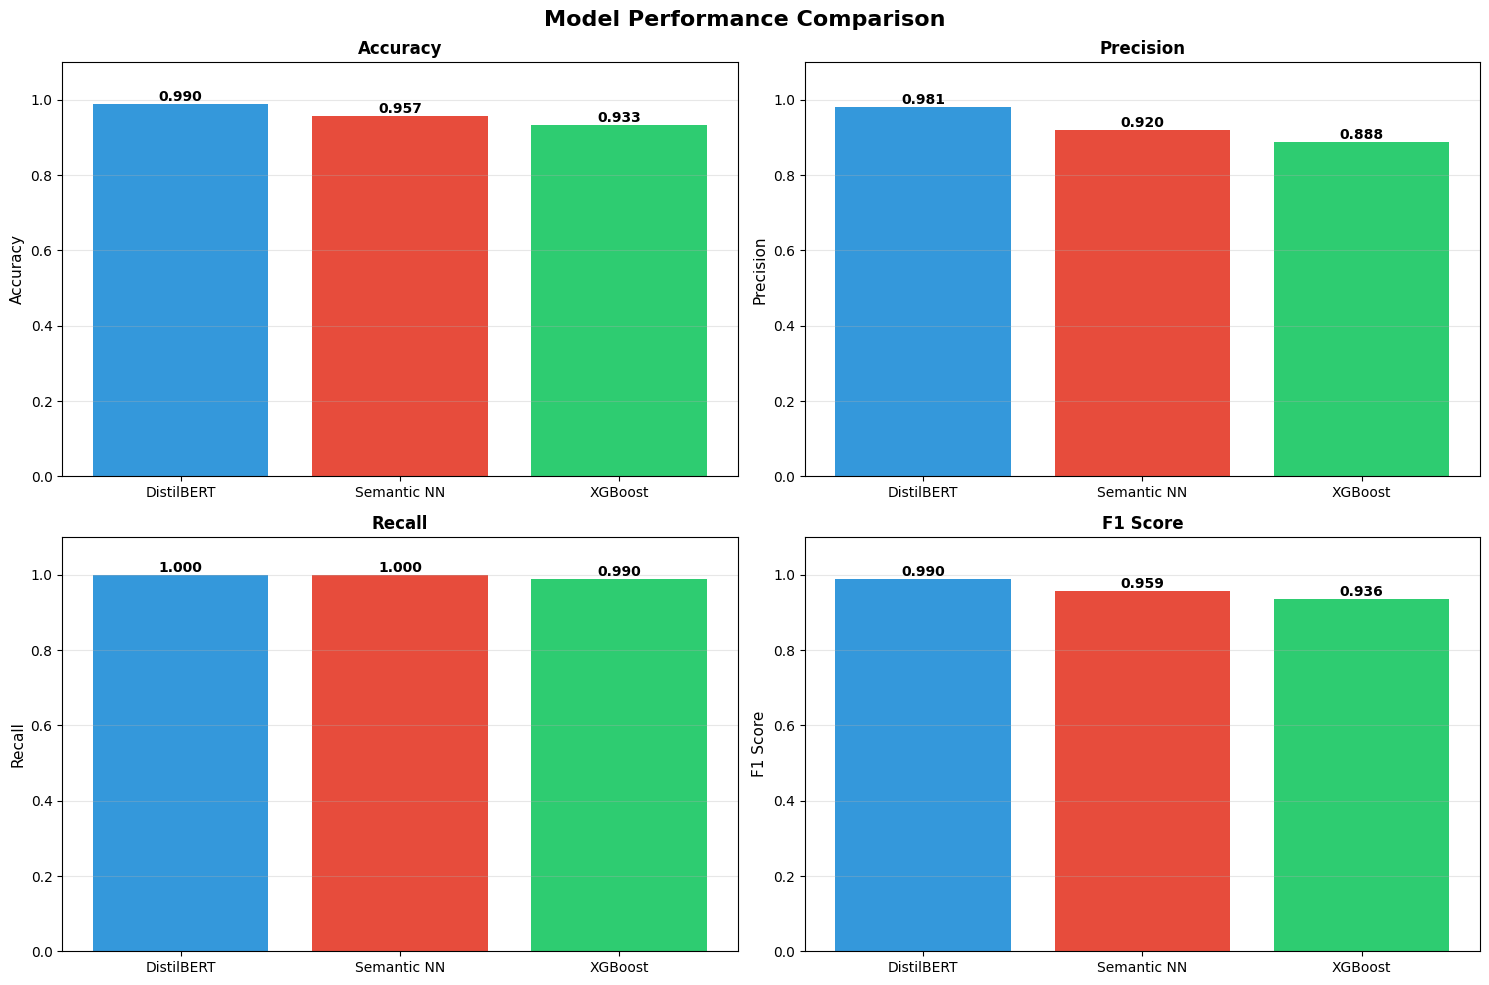

In [21]:
print("Creating visualizations...")
if len(all_results) >= 1:
    # Performance comparison chart
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    models = [r['model_name'] for r in all_results]
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    colors = ['#3498db', '#e74c3c', '#2ecc71'][:len(models)]
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        values = [r[metric] for r in all_results]
        bars = ax.bar(models, values, color=colors)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
        ax.set_ylim(0, 1.1)
        ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/home/SexyLadGD/Downloads/NLP models/model_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: model_comparison.png")
    plt.show()
else:
    print("Not enough models to create visualizations.")

✓ Saved: confusion_matrices.png


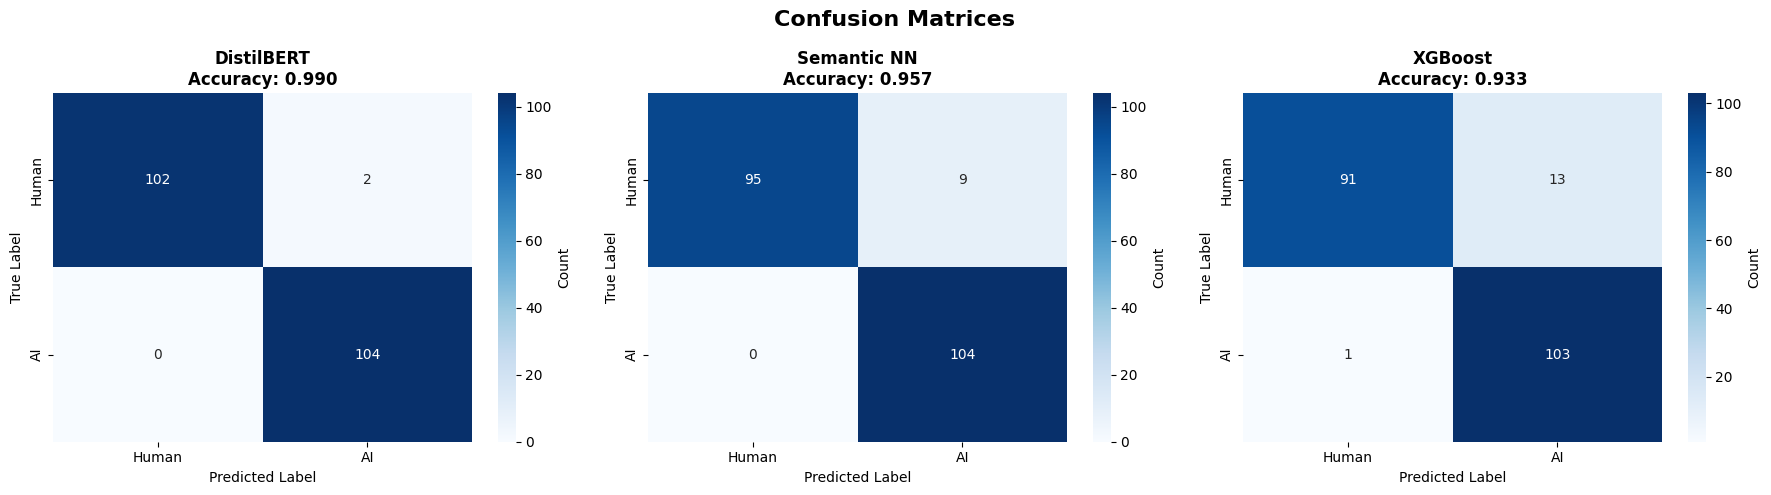


Evaluation Complete!


In [22]:
# Confusion matrices
if len(all_results) >= 1:
    num_models = len(all_results)
    fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))
    if num_models == 1:
        axes = [axes]
    fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
    
    for idx, result in enumerate(all_results):
        ax = axes[idx]
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], ax=ax,
                   cbar_kws={'label': 'Count'})
        ax.set_title(f"{result['model_name']}\nAccuracy: {result['accuracy']:.3f}", fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('/home/SexyLadGD/Downloads/NLP models/confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: confusion_matrices.png")
    plt.show()

print("\n" + "="*80)
print("Evaluation Complete!")
print("="*80)

## 9. False Positive Analysis

Review human-written texts that were incorrectly classified as AI-generated.

In [29]:
# Analyze False Positives - Human texts classified as AI
print("="*80)
print("FALSE POSITIVE ANALYSIS: Human Texts Misclassified as AI")
print("="*80)

if len(all_results) > 0:
    # Get predictions for each model
    model_predictions = {}
    
    if distilbert_results is not None:
        # Recreate DistilBERT predictions
        distilbert_model = AutoModelForSequenceClassification.from_pretrained(
            '/home/SexyLadGD/Downloads/NLP models/Distilbert model'
        )
        tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
        batch_size = 16
        distilbert_preds = []
        for i in range(0, len(test_texts), batch_size):
            batch_texts = test_texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                outputs = distilbert_model(**inputs)
                predictions = torch.argmax(outputs.logits, dim=-1)
                distilbert_preds.extend(predictions.numpy())
        model_predictions['DistilBERT'] = distilbert_preds
    
    if semantic_results is not None:
        # Recreate Semantic NN predictions
        semantic_model = keras.models.load_model(
            '/home/SexyLadGD/Downloads/NLP models/semantic_nnmodel',
            compile=False
        )
        glove_path = '/home/SexyLadGD/Downloads/NLP models/glove.6B.100d.txt'
        glove_embeddings = {}
        with open(glove_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                glove_embeddings[word] = vector
        
        def text_to_glove_vector(text):
            words = text.lower().split()
            word_vectors = [glove_embeddings[word] for word in words if word in glove_embeddings]
            return np.mean(word_vectors, axis=0) if len(word_vectors) > 0 else np.zeros(100)
        
        X_test_semantic = np.array([text_to_glove_vector(text) for text in test_texts])
        semantic_proba = semantic_model.predict(X_test_semantic, batch_size=32, verbose=0)
        semantic_preds = (semantic_proba > 0.5).astype(int).flatten()
        model_predictions['Semantic NN'] = semantic_preds
    
    if xgb_results is not None:
        # Recreate XGBoost predictions
        def extract_features(text):
            doc = nlp(text)
            tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]
            ttr = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0
            common_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'SCONJ', 'CCONJ', 'PART', 'INTJ']
            pos_counts = {tag: 0 for tag in common_pos}
            total_pos_tokens = 0
            for token in doc:
                if not token.is_punct and not token.is_space:
                    total_pos_tokens += 1
                    if token.pos_ in pos_counts:
                        pos_counts[token.pos_] += 1
            pos_ratios = {f"{tag.lower()}_ratio": count / total_pos_tokens if total_pos_tokens > 0 else 0
                          for tag, count in pos_counts.items()}
            readability = textstat.flesch_kincaid_grade(text)
            features = {"ttr": ttr, "readability": readability}
            features.update(pos_ratios)
            return features
        
        test_features = pd.DataFrame([extract_features(text) for text in test_texts])
        feature_columns = ['ttr', 'readability', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 
                          'pron_ratio', 'det_ratio', 'adp_ratio', 'aux_ratio', 'sconj_ratio', 
                          'cconj_ratio', 'part_ratio', 'intj_ratio']
        X_test_xgb = test_features[feature_columns].fillna(0).values
        xgb_model = xgb.Booster()
        xgb_model.load_model('/home/SexyLadGD/Downloads/NLP models/Xgboost model/xgboost_ai_detector.json')
        dtest = xgb.DMatrix(X_test_xgb, feature_names=feature_columns)
        xgb_proba = xgb_model.predict(dtest)
        xgb_preds = (xgb_proba > 0.5).astype(int)
        model_predictions['XGBoost'] = xgb_preds
    
    # Find false positives for each model
    for model_name, predictions in model_predictions.items():
        false_positive_indices = [i for i in range(len(test_labels)) 
                                 if test_labels[i] == 0 and predictions[i] == 1]
        
        print(f"\n{'='*80}")
        print(f"{model_name}: {len(false_positive_indices)} False Positives")
        print(f"{'='*80}\n")
        
        if len(false_positive_indices) > 0:
            for idx, fp_idx in enumerate(false_positive_indices[:10], 1):  # Show first 10
                text = test_texts[fp_idx]
                print(f"\n{'─'*80}")
                print(f"FALSE POSITIVE #{idx} | Sample Index: {fp_idx} | Length: {len(text)} chars")
                print(f"{'─'*80}")
                print(f"\n{text}\n")
                print(f"{'─'*80}")
            
            if len(false_positive_indices) > 10:
                print(f"\n... and {len(false_positive_indices) - 10} more false positives.\n")
        else:
            print("✓ No false positives for this model!\n")
    
    # Find texts misclassified by ALL models
    all_preds = list(model_predictions.values())
    if len(all_preds) > 1:
        common_fp_indices = [i for i in range(len(test_labels)) 
                            if test_labels[i] == 0 and all(pred[i] == 1 for pred in all_preds)]
        
        print(f"TEXTS MISCLASSIFIED BY ALL {len(model_predictions)} MODELS: {len(common_fp_indices)} samples")
        print(f"TEXTS MISCLASSIFIED BY ALL MODELS: {len(common_fp_indices)} samples")
        print(f"{'='*80}\n")
        
        for idx, fp_idx in enumerate(common_fp_indices, 1):  # Show all
            for idx, fp_idx in enumerate(common_fp_indices[:3], 1):  # Show first 3
                print(f"\n{'█'*80}")
                print(f"COMMON FALSE POSITIVE #{idx} | Sample Index: {fp_idx} | Length: {len(text)} chars")
                print(f"{'█'*80}")
                print(f"\n{text}\n")
                print(f"{'█'*80}\n")
        else:



            print("No models were evaluated.")
    else:
           print("✓ No texts were misclassified by all models!\n")   
           print("No models were evaluated.")

FALSE POSITIVE ANALYSIS: Human Texts Misclassified as AI


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1026.32it/s, Materializing param=pre_classifier.weight]                                  



DistilBERT: 2 False Positives


────────────────────────────────────────────────────────────────────────────────
FALSE POSITIVE #1 | Sample Index: 127 | Length: 1102 chars
────────────────────────────────────────────────────────────────────────────────

HOLMES *** The Adventures of Sherlock Holmes by Arthur Conan Doyle Contents I. A Scandal in Bohemia II. The Red-Headed League III. A Case of Identity IV. The Boscombe Valley Mystery V. The Five Orange Pips VI. The Man with the Twisted Lip VII. The Adventure of the Blue Carbuncle VIII. The Adventure of the Speckled Band IX. The Adventure of the Engineer’s Thumb X. The Adventure of the Noble Bachelor XI. The Adventure of the Beryl Coronet XII. The Adventure of the Copper Beeches I. A SCANDAL IN BOHEMIA I. To Sherlock Holmes she is always _the_ woman. I have seldom heard him mention her under any other name. In his eyes she eclipses and predominates the whole of her sex. It was not that he felt any emotion akin to love for Irene Adler. Al